In [1]:
import pickle
import matplotlib.pyplot as plt
from sac.plots import running_mean
import numpy as np

In [2]:
with open("../agents/stat(1).pkl", "rb") as in_file:
    results = pickle.load(in_file)

In [3]:
with open("basic-0-stat.pkl", "rb") as in_file:
    basic_res = pickle.load(in_file)

In [4]:
with open("strong-0-stat.pkl", "rb") as in_file:
    strong_res = pickle.load(in_file)

In [8]:
basic_res.keys()

dict_keys(['Q1_loss', 'Q2_loss', 'Policy_loss', 'Logprobs', 'Rewards', 'Scores', 'Lengths'])

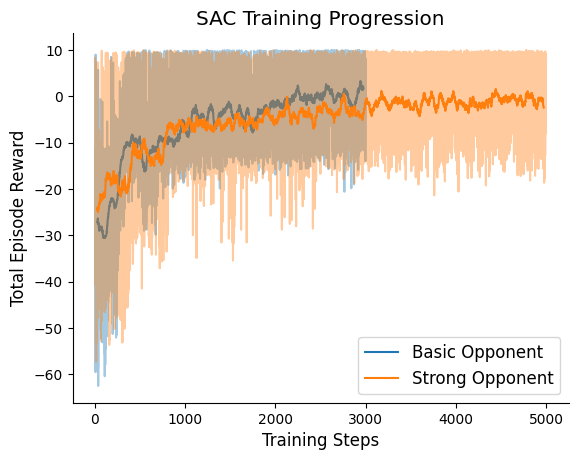

In [ ]:
# def plot_rewards(rewards, steps, ax=plt.gca(), N=50):
steps = results["Steps"]
rewards = results["Rewards"]
ax = plt.gca()
N = 50
basic_rew = basic_res["Rewards"]
x_basic = np.arange(len(basic_rew))+1
strong_rew = strong_res["Rewards"]
x_strong = np.arange(len(strong_rew))+1

x = np.cumsum(steps)
# ax.plot(x, rewards, alpha=0.4, color="tab:blue")
# ax.plot(running_mean(x, N), running_mean(rewards, N), color="tab:blue", label="Self-play")

ax.plot(x_basic, basic_rew, alpha=0.3)
ax.plot(x_strong, strong_rew, alpha=0.3, color="tab:orange")

ax.plot(running_mean(x_basic, N), running_mean(basic_rew, N), color="tab:blue", label="Basic Opponent")

ax.plot(running_mean(x_strong, N), running_mean(strong_rew, N), color="tab:orange", label="Strong Opponent")

# ax.plot(x, rewards, alpha=0.4, label="Observed Rewards")
# ax.plot(running_mean(x, N), running_mean(rewards, N), color="tab:blue", label="Moving Average")


# x.axvline(x[2318], color="black", linestyle='--', label="Best Checkpoint")
ax.set_ylabel("Total Episode Reward", fontsize='large')
ax.set_xlabel("Training Steps", fontsize='large')

# ax.set_xscale("log")

ax.spines[['top', 'right']].set_visible(False)

ax.set_title("SAC Training Progression", fontsize='x-large')

ax.legend(fontsize="large")
    # return ax
# plot_rewards(results["Rewards"], results["Steps"], plt.gca())
plt.savefig("sac_rewards.png", dpi=200, bbox_inches="tight")

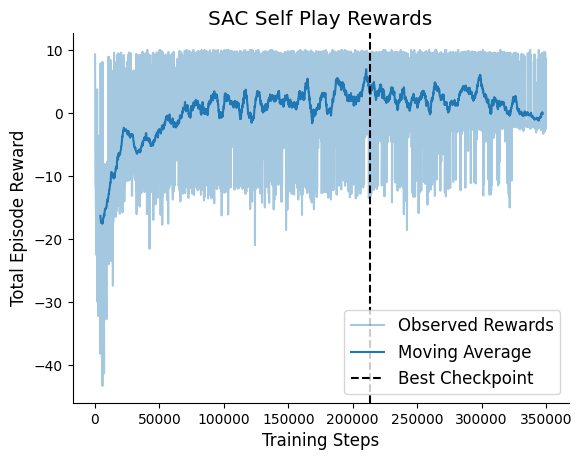

In [ ]:
def plot_rewards(rewards, steps, ax=plt.gca(), N=50):
    x = np.cumsum(steps)
    ax.plot(x, rewards, alpha=0.4, label="Observed Rewards")
    ax.plot(running_mean(x, N), running_mean(rewards, N), color="tab:blue", label="Moving Average")
    ax.axvline(x[2318], color="black", linestyle='--', label="Best Checkpoint")
    ax.set_ylabel("Total Episode Reward", fontsize='large')
    ax.set_xlabel("Training Steps", fontsize='large')

    ax.spines[['top', 'right']].set_visible(False)

    ax.set_title("SAC Self-Play Rewards", fontsize='x-large')

    ax.legend(fontsize="large")
    return ax
plot_rewards(results["Rewards"], results["Steps"], plt.gca())
plt.savefig("sac_rewards.png", dpi=200, bbox_inches="tight")

In [44]:
np.mean(results["Steps"])

np.float64(89.4126213592233)

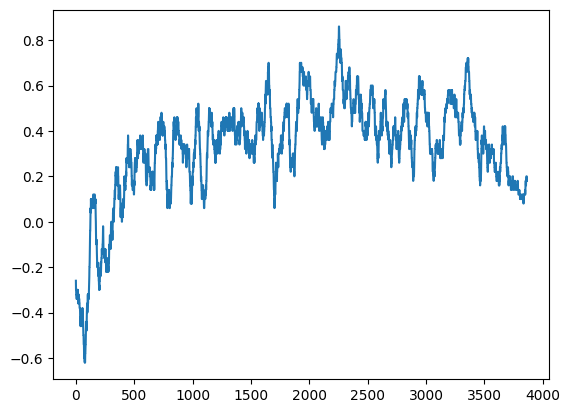

In [42]:
plt.plot(running_mean(results["Scores"], 50))

In [11]:
len(results["Rewards"])

3914